# ML OOT: stay-not-worse h=5

Сводная `ml_summary.csv` — метод × коридор на walk-forward сплитах. Обучение в CLI, не в этой тетради.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
summary = pd.read_csv(ROOT / 'reports/tables/ml_summary.csv')
summary.head()

,horizon,corridor,method,split,eligible_days,signal_count,target_positives,signal_hit_rate,random_hit_rate,freq_matched_hit_rate,lift,lift_freq_matched,bps_forward,signals_per_week,cluster_share,feature_groups
0,5,RUB->AMD,random,y2022,247,81,72,0.333333,0.291498,0.293333,1.143519,1.136364,37.322432,1.601695,0.271605,NaN
1,5,RUB->KGS,random,y2022,247,73,65,0.191781,0.263158,0.263014,0.728767,0.729167,-78.825720,1.443503,0.315068,NaN
2,5,RUB->KZT,random,y2022,247,86,64,0.325581,0.259109,0.263256,1.256541,1.236749,23.127220,1.700565,0.395349,NaN
3,5,RUB->TJS,random,y2022,247,71,77,0.366197,0.311741,0.302817,1.174684,1.209302,114.680303,1.403955,0.295775,NaN
4,5,RUB->UZS,random,y2022,247,83,65,0.313253,0.263158,0.272289,1.190361,1.150442,60.593318,1.641243,0.361446,NaN


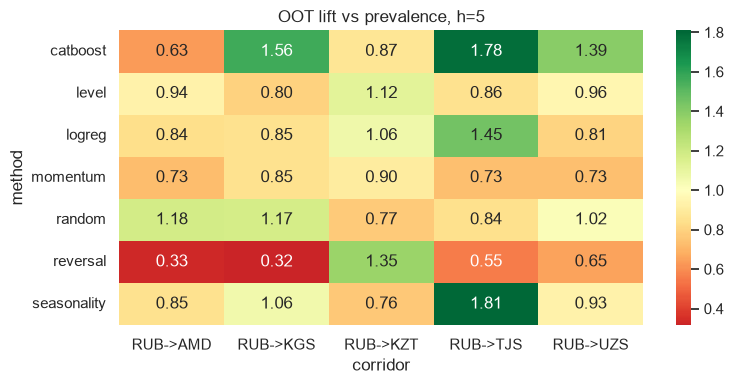

In [2]:
oot = summary[summary['split'] == 'oot'].copy()
pivot = oot.pivot_table(index='method', columns='corridor', values='lift', aggfunc='mean')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0)
plt.title('OOT lift vs prevalence, h=5')
plt.tight_layout()